In [30]:
import pandas as pd 
from sklearn.preprocessing import LabelEncoder
import mlflow
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error,root_mean_squared_error
import dagshub
import mlflow.sklearn
import mlflow.xgboost


In [31]:
df=pd.read_csv(r"C:\Users\nice\Desktop\Big Data project\Mobile-Price-prediction\Data\proccessed\processed_data.csv")

In [32]:
df.head(1)

,brand,price_inr,expandable_storage,gpu_score,cpu_score,build_material,wifi_version,chipset,ram_gb,display_type,refresh_rate_hz,battery_mah,rear_camera_mp,camera_setup,thickness_mm
0,Oppo,12672.0,0.0,1308.0,1683.0,Plastic,WiFi 5,Snapdragon 680,4.0,LCD,60.0,4866.0,50.0,"Macro, Wide",7.63


In [33]:
lab=LabelEncoder()
cat=["brand","build_material","wifi_version","chipset","display_type","camera_setup"]

for i in df[cat]:
    df[i] = lab.fit_transform(df[i])

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178835 entries, 0 to 178834
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   brand               178835 non-null  int64  
 1   price_inr           178835 non-null  float64
 2   expandable_storage  178835 non-null  float64
 3   gpu_score           178835 non-null  float64
 4   cpu_score           178835 non-null  float64
 5   build_material      178835 non-null  int64  
 6   wifi_version        178835 non-null  int64  
 7   chipset             178835 non-null  int64  
 8   ram_gb              178835 non-null  float64
 9   display_type        178835 non-null  int64  
 10  refresh_rate_hz     178835 non-null  float64
 11  battery_mah         178835 non-null  float64
 12  rear_camera_mp      178835 non-null  float64
 13  camera_setup        178835 non-null  int64  
 14  thickness_mm        178835 non-null  float64
dtypes: float64(9), int64(6)
memory usa

<Axes: >

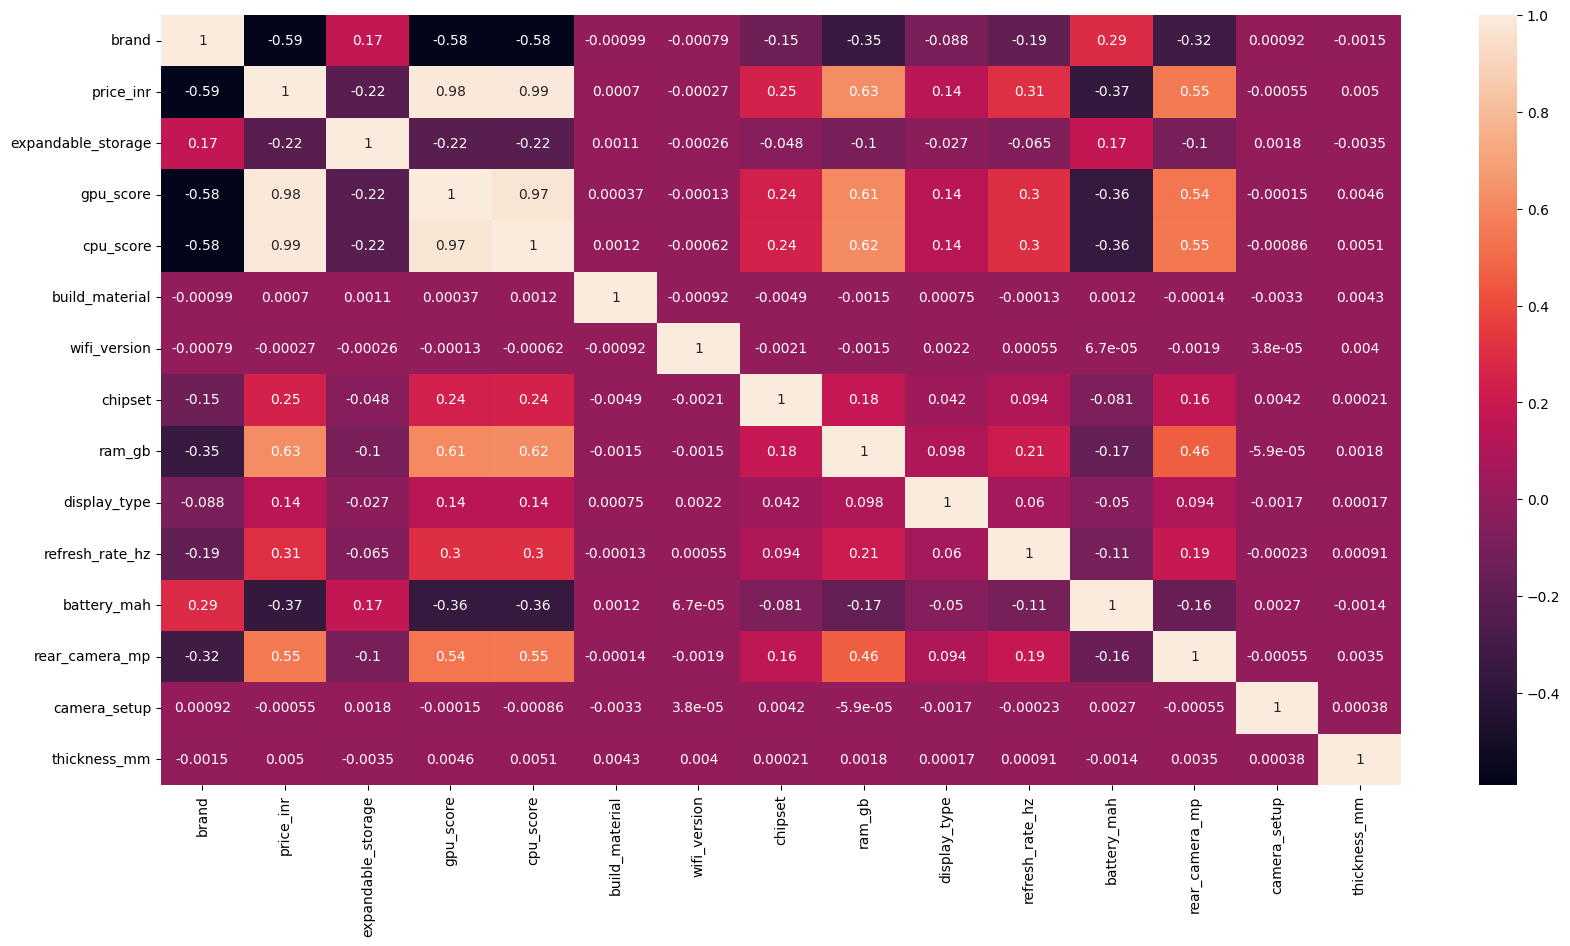

In [35]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(numeric_only=True),annot=True)

C:\Users\nice\AppData\Local\Temp\ipykernel_17672\2157131678.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation.values, y=correlation.index, palette='viridis')


Text(0.5, 0, 'Correlation Coefficient')

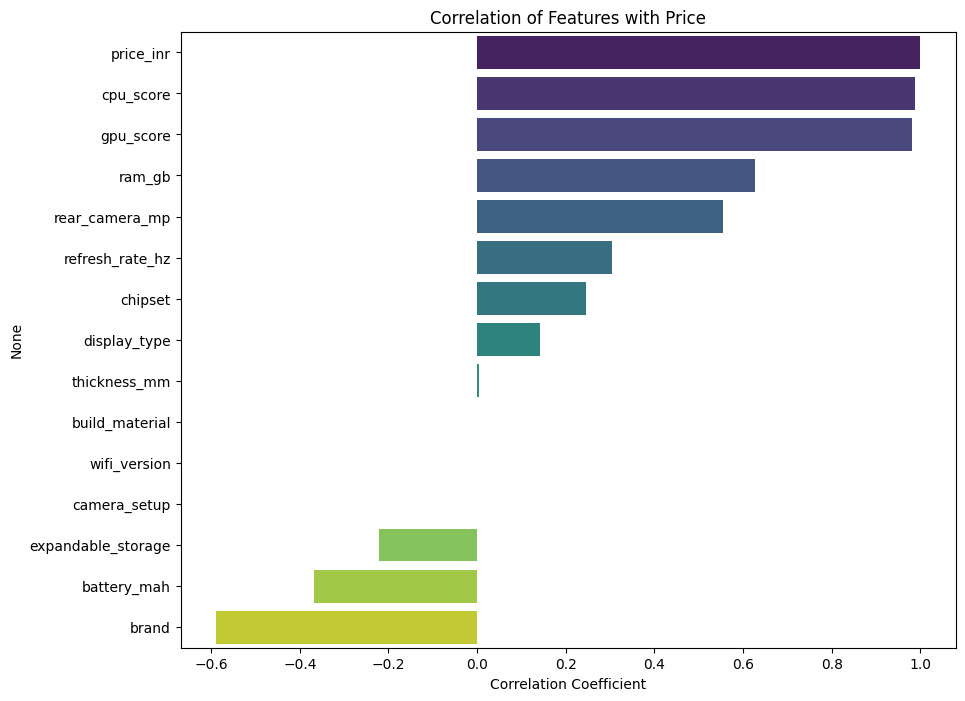

In [36]:
correlation = df.select_dtypes(include=['number']).corr()['price_inr'].sort_values(ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(x=correlation.values, y=correlation.index, palette='viridis')
plt.title('Correlation of Features with Price')
plt.xlabel('Correlation Coefficient')

In [37]:
df=df.drop(columns=["thickness_mm","build_material","wifi_version","camera_setup"],axis=1)

In [38]:
x=df.drop(columns=["price_inr"])
y=df["price_inr"]

In [39]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [40]:
import os
os.makedirs("mlruns", exist_ok=True)

In [41]:
mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("Train 3 models")

<Experiment: artifact_location=('file:///c:/Users/nice/Desktop/Big Data '
 'project/Mobile-Price-prediction/Notebook/mlruns/161821617299880957'), creation_time=1778868716002, experiment_id='161821617299880957', last_update_time=1778868716002, lifecycle_stage='active', name='Train 3 models', tags={}, trace_location=None, workspace='default'>

In [42]:
mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("Train 3 models")

mlflow.sklearn.autolog()
mlflow.xgboost.autolog()

models = {
    "Linear_regression": LinearRegression(),
    "XGB_Regressor": XGBRegressor(),
    "RandomForestRegressor": RandomForestRegressor()}

for name, model in models.items():
    with mlflow.start_run(run_name=name):
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
        metrics={
            "R2_score": r2_score(y_test, y_pred),
            "MSE": mean_squared_error(y_test, y_pred),
            "MAE": mean_absolute_error(y_test, y_pred),
            "RSME" : root_mean_squared_error(y_test,y_pred)
        }
        mlflow.log_metrics(metrics)

2026/05/16 16:11:08 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\nice\anaconda3\envs\temp\lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/05/16 16:11:08 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\nice\anaconda3\envs\temp\lib\site-pac

In [43]:
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.3, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)
with mlflow.start_run(run_name="XGB_with_Validation"):
    model = XGBRegressor(early_stopping_rounds=10)
    model.fit(x_train, y_train, eval_set=[(x_val, y_val)], verbose=False)
    y_pred=model.predict(x_test)
    metrics={
            "R2_score": r2_score(y_test, y_pred),
            "MSE": mean_squared_error(y_test, y_pred),
            "MAE": mean_absolute_error(y_test, y_pred),
            "RSME": root_mean_squared_error(y_test,y_pred)
        }
    mlflow.log_metrics(metrics)


2026/05/16 16:13:01 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\nice\anaconda3\envs\temp\lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/05/16 16:13:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/16 16:13:07 WARNING mlflow.utils.a

In [44]:
df.to_csv(r"C:\Users\nice\Desktop\Big Data project\Mobile-Price-prediction\Data\model_data\model_data.csv")